# 19 · Análisis Discriminante — Práctica (*LDA Practice*)

En el notebook anterior (18-2) aprendimos LDA con el ejemplo del amigo. Ahora vamos a **practicar** con un dataset del libro: predicción de **incumplimiento de préstamos** (*loan default*).

**Formato**: cada ejercicio tiene celdas con `___` que debes completar. Debajo hay una celda de **solución** (colapsada). Intenta resolver antes de mirar.

Predictores:
- `borrower_score` — puntaje del prestatario (0–1, mayor = más confiable)
- `payment_inc_ratio` — ratio pago/ingreso (0–20, mayor = más riesgoso)

Target: `outcome` — `"paid off"` o `"default"`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["borrower_score", "payment_inc_ratio"]
TARGET = "outcome"
CLASSES = ["default", "paid off"]  # default=0, paid off=1

## 1 · Exploración: Carga y Visualización

Carga el dataset `loans.csv` y haz un scatter plot de `borrower_score` vs `payment_inc_ratio` coloreado por `outcome`.

**Completa los `___`:**

Shape: (3000, 3)
outcome
paid off    1650
default     1350
Name: count, dtype: int64


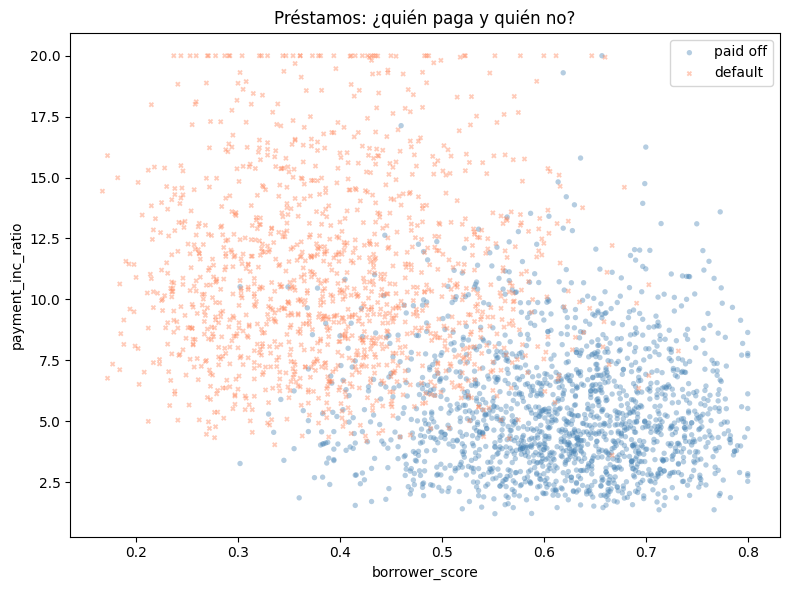

In [2]:
df = pd.read_csv("../data/loans.csv")  # 👈 Completa aquí

print(f"Shape: {df.shape}")
print(df[TARGET].value_counts())

fig, ax = plt.subplots(figsize=(8, 6))
for clase, color, marker in [("paid off", "steelblue", "o"), ("default", "coral", "X")]:
    mask = df[TARGET] == clase
    ax.scatter(
        df.loc[mask, "borrower_score"],  # 👈 Completa aquí
        df.loc[mask, "payment_inc_ratio"],
        c=color,
        marker=marker,
        s=15,
        alpha=0.4,
        label=clase,
        edgecolors="none",
    )
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")
ax.set_title("Préstamos: ¿quién paga y quién no?")
ax.legend()
plt.tight_layout()
plt.show()

## 2 · Ajustar LDA (*Fit LDA*)

Codifica el target como numérico (`default=0`, `paid off=1`) y entrena un modelo LDA.

**Pistas:**
- `"paid off"` es la clase positiva (=1)
- El modelo se importa de `sklearn.discriminant_analysis`
- Se entrena con `.fit(X, y)`

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df[PREDICTORS].to_numpy()
y = (
    (df[TARGET] == "paid off").astype(int).to_numpy()
)  # 👈 Completa aquí: ¿cuál clase es 1?

lda = LinearDiscriminantAnalysis()  # 👈 Completa aquí: ¿qué modelo?
lda.fit(X, y)  # 👈 Completa aquí: ¿qué método entrena?

print(f"Clases: {CLASSES}")
print(f"Coeficientes: {lda.coef_[0].round(4)}")
print(f"Intercepto:   {lda.intercept_[0]:.4f}")
print(f"Accuracy:     {lda.score(X, y):.1%}")

Clases: ['default', 'paid off']
Coeficientes: [21.7359 -0.5484]
Intercepto:   -6.2901
Accuracy:     90.4%


## 3 · Pesos Discriminantes (*Discriminant Weights*)

Los coeficientes `lda.coef_[0]` son los pesos de la función discriminante: `[w_borrower, w_ratio]`.

- Peso **positivo** para `borrower_score` → mayor score empuja hacia "paid off"
- Peso **negativo** para `payment_inc_ratio` → mayor ratio empuja hacia "default"

Pero cuidado: los predictores tienen **escalas diferentes**. No puedes comparar pesos brutos directamente.

In [14]:
w = lda.coef_[0]
print(f"w(borrower_score)    = {w[0]:+.4f}")
print(f"w(payment_inc_ratio) = {w[1]:+.4f}")

# ¿Cuál predictor tiene más peso absoluto?
mas_importante = PREDICTORS[np.argmax(np.abs([w[0], w[1]]))]  # 👈 Completa aquí
print(f"\nEl predictor con más peso bruto: {mas_importante}")
print("⚠️  Pero cuidado: los predictores tienen escalas diferentes!")
print(
    f"  borrower_score rango:    {df['borrower_score'].min():.2f} – {df['borrower_score'].max():.2f}"
)
print(
    f"  payment_inc_ratio rango: {df['payment_inc_ratio'].min():.1f} – {df['payment_inc_ratio'].max():.1f}"
)  # 👈 Completa aquí

w(borrower_score)    = +21.7359
w(payment_inc_ratio) = -0.5484

El predictor con más peso bruto: borrower_score
⚠️  Pero cuidado: los predictores tienen escalas diferentes!
  borrower_score rango:    0.17 – 0.80
  payment_inc_ratio rango: 1.2 – 20.0


## 4 · Normalizar para Comparar Importancia (*Feature Selection*)

Si **normalizamos** los predictores (media=0, desviación=1) antes de ajustar LDA, los pesos se vuelven **comparables**. Esto es lo que el libro menciona como método de *feature selection*.

**Pistas:**
- Usa `StandardScaler` de sklearn para normalizar
- Ajusta un **nuevo** LDA sobre los datos normalizados

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # 👈 Completa aquí
X_scaled = scaler.fit_transform(X)  # 👈 Completa aquí: ¿qué datos normalizar?

lda_scaled = LinearDiscriminantAnalysis()
lda_scaled.fit(X_scaled, y)

w_scaled = lda_scaled.coef_[0]
print("Pesos con predictores normalizados:")
for name, weight in zip(PREDICTORS, w_scaled):
    print(f"  {name:25s} → {weight:+.4f}")

print(
    f"\nAhora sí podemos comparar: el predictor más importante es "
    f"{PREDICTORS[np.argmax(np.abs(w_scaled))]}."
)  # 👈 Completa aquí

Pesos con predictores normalizados:
  borrower_score            → +3.2161
  payment_inc_ratio         → -2.2973

Ahora sí podemos comparar: el predictor más importante es borrower_score.


## 5 · Predicción de Probabilidades (*predict_proba*)

LDA no solo clasifica — da **probabilidades**. Esto es crucial para gestión de riesgo: no es lo mismo un préstamo con 51% de probabilidad de default que uno con 95%.

**Pistas:**
- El método se llama `predict_proba`
- Retorna un array con columnas `[P(default), P(paid off)]`
- `default` es la clase 0 (índice 0)

In [16]:
escenarios = pd.DataFrame(
    {
        "borrower_score": [0.70, 0.25, 0.50, 0.40],
        "payment_inc_ratio": [3.0, 16.0, 10.0, 7.0],
    }
)

probas = lda.predict_proba(escenarios.values)  # 👈 Completa aquí
preds = lda.predict(escenarios.values)

for i, row in escenarios.iterrows():
    label = CLASSES[int(preds[i])]
    p_default = probas[i, 0]  # 👈 Completa aquí: ¿índice de "default"?
    print(
        f"score={row['borrower_score']:.2f}, ratio={row['payment_inc_ratio']:.1f}"
        f"  →  P(default)={p_default:.1%}  →  {label}"
    )

score=0.70, ratio=3.0  →  P(default)=0.1%  →  paid off
score=0.25, ratio=16.0  →  P(default)=100.0%  →  default
score=0.50, ratio=10.0  →  P(default)=71.2%  →  default
score=0.40, ratio=7.0  →  P(default)=80.8%  →  default


## 6 · Frontera con Gradiente de Color (*Decision Boundary*)

En vez de colorear regiones como dos colores planos, usamos un **gradiente** que muestra P(default) como mapa de calor. La frontera de decisión es la línea donde P(default) = 50%.

**Pistas:**
- `predict_proba(...)[:, 0]` da P(default) — la columna 0
- `"RdBu_r"` es un colormap rojo-azul (rojo = alto riesgo)
- La frontera está en el nivel `0.5`

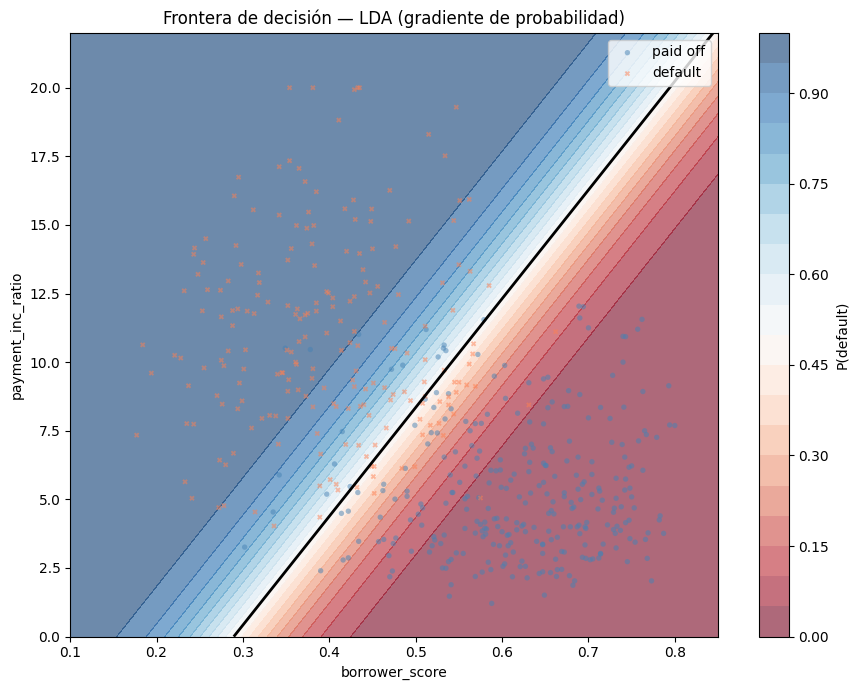

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

# Crear grid
x_min, x_max = 0.10, 0.85
y_min, y_max = 0, 22
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Probabilidad de default en cada punto del grid
Z = lda.predict_proba(grid)[:, 0].reshape(xx.shape)  # 👈 Completa aquí

# Gradiente de color
contour = ax.contourf(
    xx, yy, Z, levels=20, cmap="RdBu", alpha=0.6
)  # 👈 Completa aquí: cmap rojo-azul
plt.colorbar(contour, ax=ax, label="P(default)")

# Línea de frontera al 50%
ax.contour(xx, yy, Z, levels=[0.5], colors=["black"], linewidths=2)  # 👈 Completa aquí

# Puntos (muestra de 500 para no saturar)
sample = df.sample(500, random_state=42)
for clase, color, marker in [("paid off", "steelblue", "o"), ("default", "coral", "X")]:
    mask = sample[TARGET] == clase
    ax.scatter(
        sample.loc[mask, "borrower_score"],
        sample.loc[mask, "payment_inc_ratio"],
        c=color,
        marker=marker,
        s=15,
        alpha=0.5,
        label=clase,
        edgecolors="none",
    )

ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")
ax.set_title("Frontera de decisión — LDA (gradiente de probabilidad)")
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Ecuación de la Frontera (*Decision Boundary Line*)

La frontera de LDA es una **línea recta** definida por:

$$w_1 \cdot \text{borrower\_score} + w_2 \cdot \text{payment\_inc\_ratio} + b = 0$$

Despejando `payment_inc_ratio`:

$$\text{payment\_inc\_ratio} = \underbrace{-\frac{w_1}{w_2}}_{\text{slope}} \cdot \text{borrower\_score} + \underbrace{-\frac{b}{w_2}}_{\text{intercept}}$$

**Pistas:**
- `w1, w2 = lda.coef_[0]` y `b = lda.intercept_[0]`
- slope = -w1 / w2
- intercept = -b / w2

Ecuación de la frontera:
  payment_inc_ratio = 39.6367 * borrower_score + -11.4704


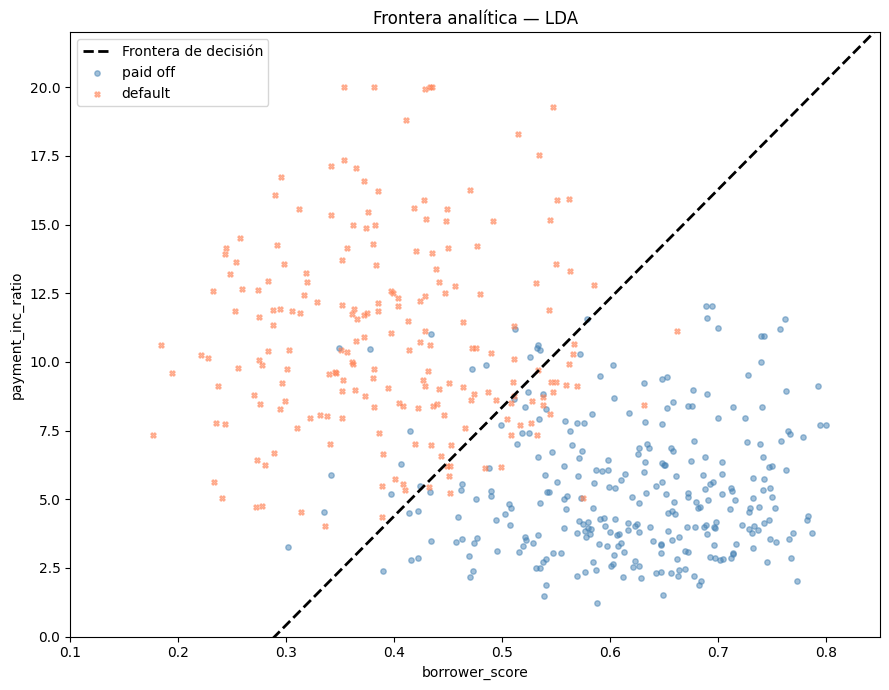

In [19]:
w1, w2 = lda.coef_[0]
b = lda.intercept_[0]

# Pendiente de la frontera
slope = -w1 / w2  # 👈 Completa aquí
# Intercepto de la frontera
intercept = -b / w2  # 👈 Completa aquí

print(f"Ecuación de la frontera:")
print(f"  payment_inc_ratio = {slope:.4f} * borrower_score + {intercept:.4f}")

# Dibujar la línea sobre el scatter
fig, ax = plt.subplots(figsize=(9, 7))
x_line = np.linspace(0.10, 0.85, 100)
y_line = slope * x_line + intercept  # 👈 Completa aquí

ax.plot(x_line, y_line, "k--", linewidth=2, label="Frontera de decisión")

sample = df.sample(500, random_state=42)
for clase, color, marker in [("paid off", "steelblue", "o"), ("default", "coral", "X")]:
    mask = sample[TARGET] == clase
    ax.scatter(
        sample.loc[mask, "borrower_score"],
        sample.loc[mask, "payment_inc_ratio"],
        c=color,
        marker=marker,
        s=15,
        alpha=0.5,
        label=clase,
    )

ax.set_xlim(0.10, 0.85)
ax.set_ylim(0, 22)
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")
ax.set_title("Frontera analítica — LDA")
ax.legend()
plt.tight_layout()
plt.show()

## 8 · QDA — Análisis Discriminante Cuadrático (*Quadratic Discriminant Analysis*)

LDA asume que ambas clases comparten la **misma** matriz de covarianza. QDA relaja esta restricción: cada clase tiene su propia covarianza. Resultado: la frontera puede ser **curva**.

**Pistas:**
- Se importa de `sklearn.discriminant_analysis`
- Se usa exactamente igual que LDA: `.fit(X, y)`, `.predict_proba(...)`, etc.

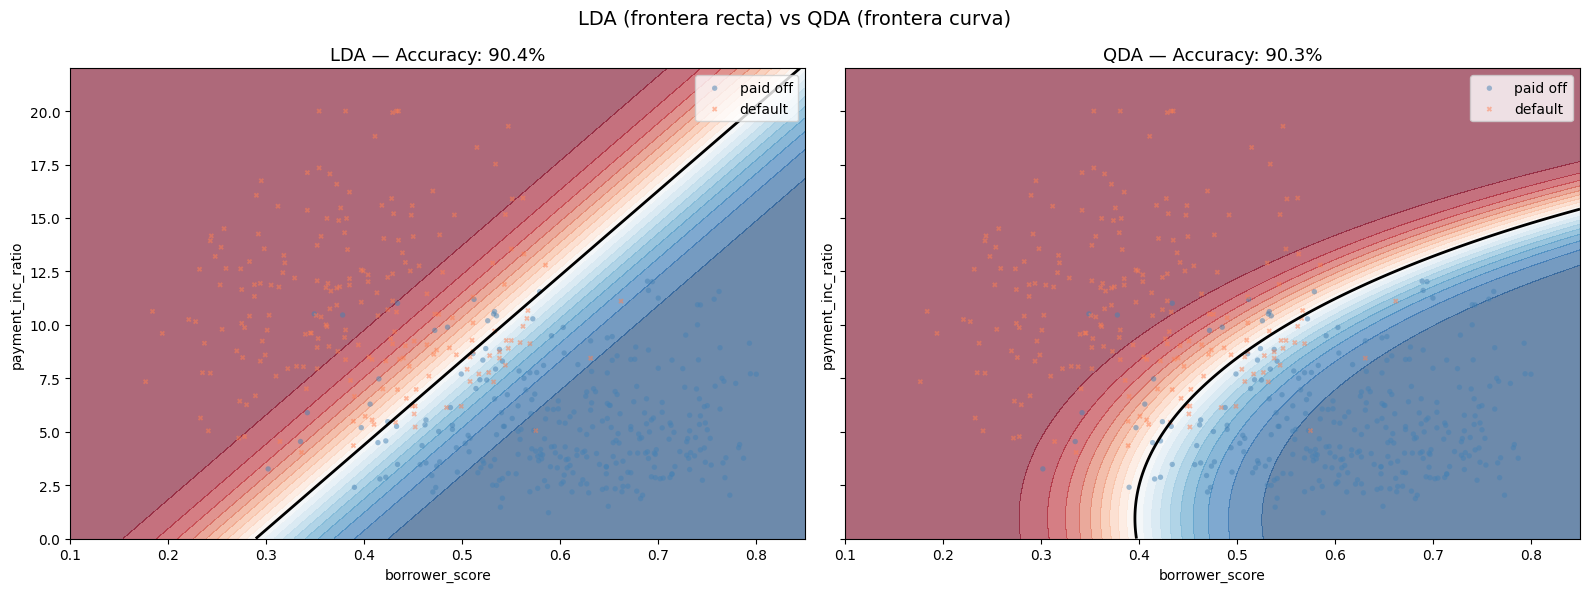

In [20]:
from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
)  # 👈 Completa aquí

qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)

# Comparar fronteras: LDA vs QDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for ax, (name, model) in zip(axes, [("LDA", lda), ("QDA", qda)]):  # 👈 Completa aquí
    Z = model.predict_proba(grid)[:, 0].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors=["black"], linewidths=2)

    sample = df.sample(500, random_state=42)
    for clase, color, marker in [
        ("paid off", "steelblue", "o"),
        ("default", "coral", "X"),
    ]:
        mask = sample[TARGET] == clase
        ax.scatter(
            sample.loc[mask, "borrower_score"],
            sample.loc[mask, "payment_inc_ratio"],
            c=color,
            marker=marker,
            s=15,
            alpha=0.5,
            label=clase,
            edgecolors="none",
        )

    acc = model.score(X, y)
    ax.set_title(f"{name} — Accuracy: {acc:.1%}", fontsize=13)
    ax.set_xlabel("borrower_score")
    ax.set_ylabel("payment_inc_ratio")
    ax.legend()

plt.suptitle("LDA (frontera recta) vs QDA (frontera curva)", fontsize=14)
plt.tight_layout()
plt.show()

## 9 · Desafio Final: Predictor Nuevo (*Feature Engineering*)

Crea un nuevo predictor `risk_index = payment_inc_ratio / borrower_score` que combina ambos predictores en uno. Reajusta LDA con 3 predictores y compara si mejora el accuracy.

**Piensa:** un `risk_index` alto significa ratio alto + score bajo = muy riesgoso.

In [22]:
# Crear nuevo predictor
df["risk_index"] = df["payment_inc_ratio"] / df["borrower_score"]  # 👈 Completa aquí

PREDICTORS_3 = ["borrower_score", "payment_inc_ratio", "risk_index"]
X3 = df[PREDICTORS_3].values

lda_3 = LinearDiscriminantAnalysis()
lda_3.fit(X3, y)  # 👈 Completa aquí

acc_2 = lda.score(X, y)
acc_3 = lda_3.score(X3, y)  # 👈 Completa aquí

print(f"Accuracy con 2 predictores: {acc_2:.1%}")
print(f"Accuracy con 3 predictores: {acc_3:.1%}")
print(f"\n→ {'Mejora' if acc_3 > acc_2 else 'No mejora'} al agregar risk_index")
print("  (Un predictor derivado no siempre ayuda si LDA ya captura la relación lineal)")

Accuracy con 2 predictores: 90.4%
Accuracy con 3 predictores: 90.4%

→ No mejora al agregar risk_index
  (Un predictor derivado no siempre ayuda si LDA ya captura la relación lineal)


## 10 · Resumen

| Concepto | Lo que practicaste |
|----------|-------------------|
| `fit(X, y)` | Entrenar LDA con dos predictores numéricos |
| `coef_` | Leer e interpretar los pesos discriminantes |
| Normalizar predictores | Comparar importancia de features con escalas diferentes |
| `predict_proba` | Obtener probabilidades, no solo clases |
| Frontera con gradiente | Visualizar P(default) como mapa de calor |
| Ecuación de la frontera | `slope = -w1/w2`, `intercept = -b/w2` |
| QDA | Relajar la asunción de covarianza compartida → frontera curva |
| Feature engineering | Agregar predictor derivado y evaluar si mejora el modelo |

| LDA | QDA |
|-----|-----|
| Covarianza compartida entre clases | Cada clase su propia covarianza |
| Frontera siempre recta | Frontera puede ser curva |
| Menos parámetros → más robusto | Más flexible → riesgo de sobreajuste |

> 👈 En la práctica, LDA y QDA suelen dar resultados similares. La diferencia importa más cuando las clases tienen distribuciones muy diferentes.